# Introdução

Este relatório tem como objetivo identificar, mensurar e propor soluções para o gargalo observado no Dashboard de Vendas do evento de São Paulo, concentrado precipuamente na etapa de Negociação do funil.

A partir do acompanhamento dos indicadores, constatou-se que a maioria dos leads encontra-se retida nessa fase. Faltando 57 dias para a realização do evento e com apenas 4% da meta de faturamento atingida, torna-se indispensável analisar as causas dessa estagnação e estruturar ações prescritivas pautadas em dados para viabilizar a conversão no tempo hábil.

---

# Objetivo

O presente estudo visa diagnosticar a dinâmica do ciclo de vida (life cycle) dos expositores e parametrizar um modelo de eficiência comercial. Por meio do benchmark interno de eventos anteriores, busca-se estabelecer SLAs estratégicos por etapa do funil e definir o ritmo de conversão diário/semanal necessário para destravar a etapa de negociação e garantir o atingimento da meta global.

---

# Estudo

In [12]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()

project_root = Path.cwd().parent
dash_dir = project_root

for path in (str(project_root), str(dash_dir)):
    if path not in sys.path:
        sys.path.insert(0, path)


db_uri = os.getenv("db_uri")
from app.database import DatabaseManager

db = DatabaseManager(db_uri)
df_reservas_all = db.carregar_reservas()

df_reservas_all.head()

INFO:DatabaseManager:Engine do Banco de Dados inicializado com sucesso.
INFO:DatabaseManager:Carregadas 232 linhas da tabela 'reservas_cvcrm'.


,id_reserva,id_proposta_cv,id_proposta_int,data_cadastro,data_venda,data_contrato,data_cancelamento,vendida_flag,id_situacao,situacao,...,titular_estado,titular_email,titular_telefone,como_ficou_sabendo,imobiliaria_nome,corretor_nome,corretor_email,observacoes,aprovada_financeiramente,solicitacao_distrato
0,222,222,NaN,2026-06-30 14:12:32,NaT,NaT,NaT,N,1,Proposta Enviada,...,NaN,monteiro.giovane@ophicina.com,+5519983517700,Telefone,EXAGERADO RIO,Henrique dos Santos Rodrigues,henrique.rodrigues@alfaiatariadeideias.com.br,,N,N
1,277,277,NaN,2026-07-01 16:39:32,NaT,NaT,NaT,N,1,Proposta Enviada,...,NaN,eduardordutra17@gmail.com,+5521999762397,Telefone,EXAGERADO RIO,Henrique dos Santos Rodrigues,henrique.rodrigues@alfaiatariadeideias.com.br,"PROPOSTA ENVIADA, EM NEGOCIAÇÃO",N,N
2,283,283,NaN,2026-07-02 16:10:37,NaT,NaT,NaT,N,1,Proposta Enviada,...,NaN,CODIGOX@GMAIL.COM,+552799761826,Telefone,EXAGERADO RIO,Henrique dos Santos Rodrigues,henrique.rodrigues@alfaiatariadeideias.com.br,,N,N
3,293,293,NaN,2026-07-06 15:18:58,NaT,NaT,NaT,N,1,Proposta Enviada,...,NaN,contato@urcabeachfit.com.br,+5521982509784,Telefone,EXAGERADO RIO,Henrique dos Santos Rodrigues,henrique.rodrigues@alfaiatariadeideias.com.br,EM NEGOCIAÇÃO,N,N
4,294,294,NaN,2026-07-07 14:02:38,NaT,NaT,NaT,N,1,Proposta Enviada,...,NaN,contato@s2grupo.com.br,+55549144322,Telefone,EXAGERADO RIO,Henrique dos Santos Rodrigues,henrique.rodrigues@alfaiatariadeideias.com.br,Em negociação.,N,N


Filtrando todos os expositores vendidos, temos que o tempo mediano de quando um expositor chega no funil de venda e até o tempo que ele é vendido de fato, isso é, o ciclo de vida em dias, é:

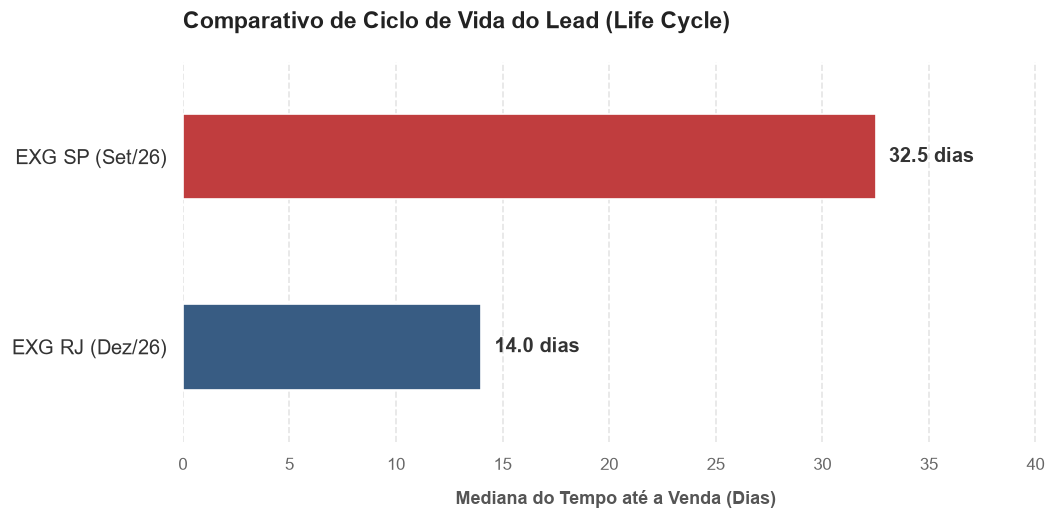

In [ ]:
df_data_venda = df_reservas_all[df_reservas_all["data_cadastro"].notnull() & df_reservas_all["data_venda"].notnull() & df_reservas_all["empreendimento"].notnull()][["data_cadastro", "data_venda", "empreendimento"]]

df_data_venda['tempo_ate_venda'] = (df_data_venda['data_venda'] - df_data_venda['data_cadastro']).dt.days

df_data_venda = df_data_venda[['empreendimento', 'tempo_ate_venda']]
df_medianas = (
    df_data_venda.groupby('empreendimento')['tempo_ate_venda']
    .median()
    .reset_index()
    .rename(columns={'tempo_ate_venda': 'mediana_tempo_ate_venda'})
    .sort_values(by='mediana_tempo_ate_venda', ascending=False)
)

df_medianas['empreendimento_label'] = df_medianas['empreendimento'].map({
    'EXG SP SET 2026 - MEU EXG': 'EXG SP (Set/26)',
    'EXG RJ DEZ 2026 - MEU EXG': 'EXG RJ (Dez/26)'
}).fillna(df_medianas['empreendimento'])

palette_dict = {
    label: ('#D62728' if 'SP' in label else '#2B5C8F')
    for label in df_medianas['empreendimento_label']
}

sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)

bars = sns.barplot(
    data=df_medianas,
    x='mediana_tempo_ate_venda',
    y='empreendimento_label',
    hue='empreendimento_label',
    palette=palette_dict,
    ax=ax,
    width=0.45,
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    if width > 0: 
        ax.annotate(
            f'{width:.1f} dias',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(8, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='#333333'
        )

ax.set_title('Comparativo de Ciclo de Vida do Lead (Life Cycle)', fontsize=14, fontweight='bold', pad=20, loc='left', color='#222222')
ax.set_xlabel('Mediana do Tempo até a Venda (Dias)', fontsize=11, fontweight='semibold', labelpad=10, color='#555555')
ax.set_ylabel('', fontsize=11)

ax.set_xlim(0, df_medianas['mediana_tempo_ate_venda'].max() * 1.25)

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(False)

ax.tick_params(axis='y', labelsize=12, colors='#333333')
ax.tick_params(axis='x', labelsize=10, colors='#666666')

plt.tight_layout()


Ao analisar a mediana do tempo até a venda (`tempo_ate_venda`) por empreendimento, identificamos uma discrepância crítica na velocidade de conversão dos leads:

* **EXG SP SET 2026:** **32,5 dias**
* **EXG RJ DEZ 2026:** **14,0 dias**

**Diagnóstico:**  
A operação do evento em **São Paulo** apresenta um ciclo de vendas com mais do dobro do tempo observado no **Rio de Janeiro**. 

No entanto, o benchmark interno do Rio comprova ser plenamente viável converter um expositor em apenas **14 dias (2 semanas)** — mesmo considerando a complexidade logística do perfil de seus participantes, cuja distância mediana até o local do evento é de **356 km** (operação de caráter interestadual).

Se o time comercial já demonstrou capacidade de convencer e fechar negócios com clientes de fora do estado em um intervalo de duas semanas, o ciclo atual de **32,5 dias em SP** revela-se um gargalo operacional superável.

Comprovada a viabilidade do ciclo mediano de 14 dias, podemos desdobrar as consequências operacionais e os ganhos de ritmo necessários para o atingimento da meta em São Paulo.

---

### Origem dos Dados e Desdobramento Matemático

Para viabilizar a meta global de faturamento dentro do prazo restante, a meta financeira foi convertida em métricas operacionais de volume de área ($m^2$), quantidade de stands e ritmo semanal de fechamento.

#### 1. Parâmetros de Entrada
* **Meta Global de Faturamento (SP):** $\text{R\$ } 1.440.000,00$
* **Preço do $m^2$:** $\text{R\$ } 616,00/\text{m}^2$
* **Tamanho Médio por Stand:** $20\text{ m}^2$
* **Tempo Restante até o Evento:** $57\text{ dias}$
* **Benchmark de Life Cycle (RJ):** $14\text{ dias}$ por ciclo

---

#### 2. Cálculo da Metragem e Total de Stands

* **Volume de Área Necessário:**
  $$\text{Área Total} = \frac{\text{R\$ } 1.440.000}{\text{R\$ } 616/\text{m}^2} \approx 2.337,66\text{ m}^2$$

* **Volume Total de Stands Necessários:**
  $$\text{Total de Stands} = \frac{2.337,66\text{ m}^2}{20\text{ m}^2/\text{stand}} \approx 117\text{ stands}$$

---

#### 3. Projeção de Ciclos e Ritmo de Vendas

Considerando os $57\text{ dias}$ restantes até o evento e adotando a cadência de **2 semanas (14 dias)** do benchmark do Rio:

* **Janela Operacional em Ciclos de Venda:**
  $$\text{Total de Ciclos} = \frac{57\text{ dias}}{14\text{ dias/ciclo}} \approx 4\text{ ciclos operacionais completo}$$

* **Meta de Conversão por Ciclo (14 dias):**
  $$\text{Stands por Ciclo} = \frac{117\text{ stands}}{4\text{ ciclos}} \approx 29,25 \implies \mathbf{\sim 29\text{ a } 30\text{ stands/ciclo}}$$

* **Ritmo Semanal Exigido pela Operação:**
  $$\text{Stands por Semana} = \frac{29,25\text{ stands}}{2\text{ semanas}} \approx \mathbf{14,6\text{ stands/semana}}$$

---

### Conclusão e Validação da Capacidade Comercial

O desdobramento analítico demonstra que o atingimento da meta de **R$ 1,44M** exige uma conversão contínua de aproximadamente **15 stands por semana** (ou ~30 por ciclo de 14 dias). 

Esse resultado valida numericamente a capacidade estipulada para a equipe comercial (composta por 2 vendedores, com meta de 7 a 8 vendas/semana cada). No entanto, o fator crítico para a viabilização dessa cadência não reside na força bruta de prospecção, mas sim na **redução do tempo médio do ciclo de vida (*life cycle*) em SP para o patamar de 14 dias**, destravando gargalos na etapa de negociação e mantendo o fluxo de conversão constante.

---

### Mapeamento do Funil de Vendas (São Paulo)

A análise da distribuição dos leads por etapa da situação comercial expõe de forma clara onde está retida a maior parte da receita em potencial do evento de São Paulo:

C:\Users\KauãDias\AppData\Local\Temp\ipykernel_3132\3747030664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


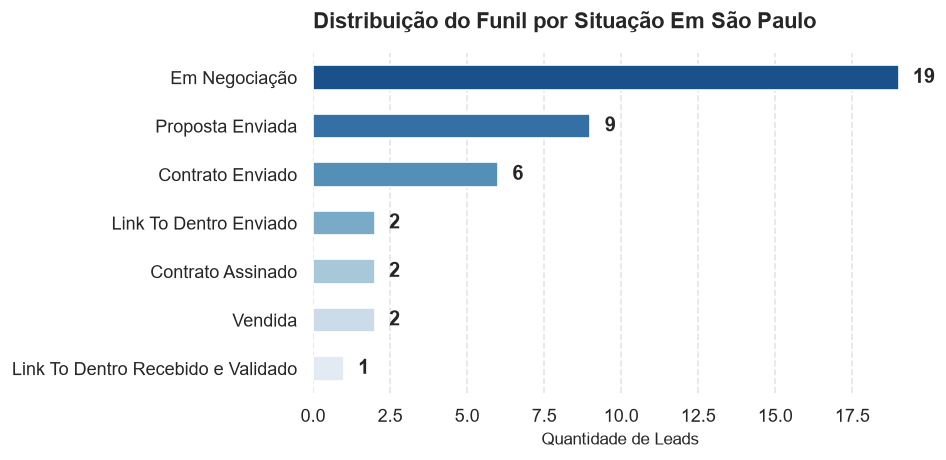

In [ ]:
df_sp = df_reservas_all[df_reservas_all["empreendimento"] == "EXG SP SET 2026 - MEU EXG"]

funil_df = df_sp["situacao"].value_counts().reset_index()
funil_df.columns = ["situacao", "quantidade"]

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
sns.barplot(
    data=funil_df,
    x="quantidade",
    y="situacao",
    palette="Blues_r",
    ax=ax,
    width=0.5,
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f" {int(width)}",
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontweight="bold",
    )

ax.set_title(
    "Distribuição do Funil por Situação Em São Paulo",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Quantidade de Leads", fontsize=10)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Diagnóstico do Funil:**

- Concentração no Gargalo: A etapa de Em Negociação lidera isoladamente o volume de contatos, acumulando 19 leads — o que representa quase o dobro da segunda maior etapa (Proposta Enviada, com 9).

- Conversão Efetiva Atual: Apenas 4 contratos já avançaram para as etapas finais de fechamento (Contrato Assinado e Vendida), reforçando a baixa taxa de avanço do topo para o fim do funil no cenário atual.

### Próximo Passo (Análise de Aging):

A etapa de negociação é o ponto focal de atenção da operação. Para determinar se esses 19 expositores representam oportunidades quentes com fechamento iminente ou leads estagnados que estão inflando o tempo do ciclo, filtraremos exclusivamente esta base no próximo tópico para calcular o tempo exato de permanência (aging) de cada um no funil frente ao nosso SLA ideal.

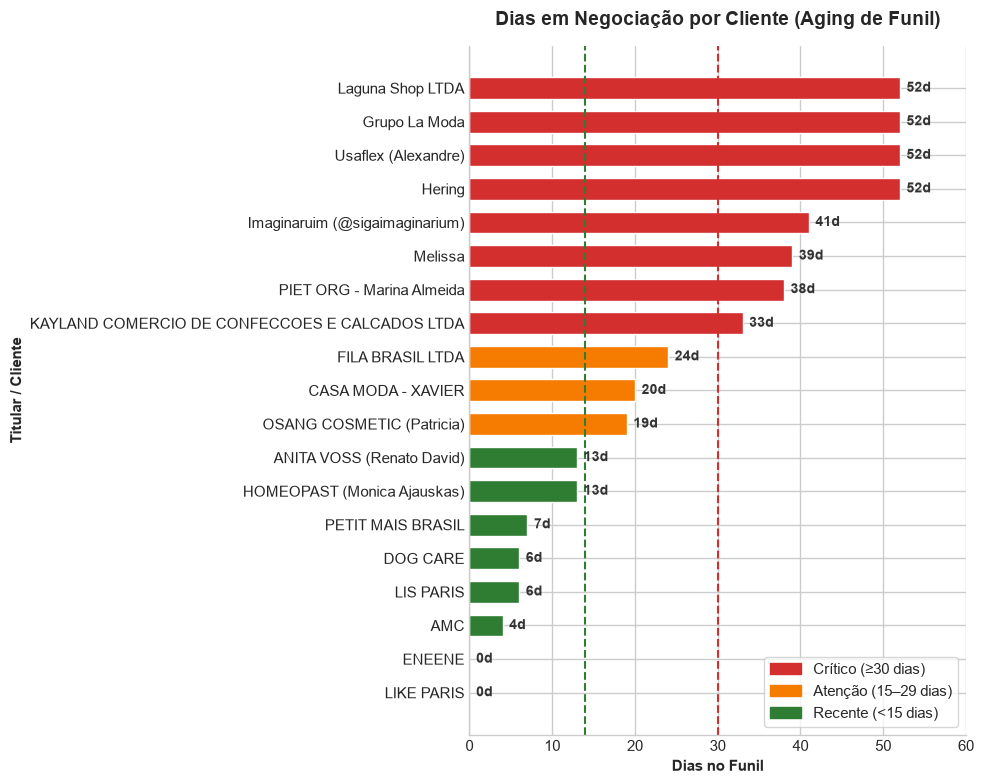

In [57]:
df_sp_neg = df_sp[df_sp["situacao"] == "Em Negociação"][["data_cadastro", "titular_nome", 'valor_contrato']]


hoje = pd.Timestamp.now().normalize()
df_sp_neg["dias_no_funil"] = (hoje - df_sp_neg["data_cadastro"]).dt.days
df_sp_neg[["titular_nome", "dias_no_funil"]]

df_sorted = df_sp_neg.sort_values(by="dias_no_funil", ascending=True).reset_index(drop=True)

colors = []
for d in df_sorted["dias_no_funil"]:
    if d >= 30:
        colors.append('#D32F2F') 
    elif d >= 15:
        colors.append('#F57C00') 
    else:
        colors.append('#2E7D32') 

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(df_sorted["titular_nome"], df_sorted["dias_no_funil"], color=colors, height=0.65)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.8, bar.get_y() + bar.get_height()/2, f'{int(width)}d', 
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

ax.axvline(x=30, color='#D32F2F', linestyle='--', linewidth=1.5, label='Alerta: 30+ Dias')
ax.axvline(x=14, color='#2E7D32', linestyle='--', linewidth=1.5, label='Benchmark Rio: 14 dias')

ax.set_title("Dias em Negociação por Cliente (Aging de Funil)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Dias no Funil", fontsize=11, fontweight='bold')
ax.set_ylabel("Titular / Cliente", fontsize=11, fontweight='bold')
ax.set_xlim(0, 60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#D32F2F', label='Crítico (≥30 dias)')
orange_patch = mpatches.Patch(color='#F57C00', label='Atenção (15–29 dias)')
green_patch = mpatches.Patch(color='#2E7D32', label='Recente (<15 dias)')
plt.legend(handles=[red_patch, orange_patch, green_patch], loc='lower right', frameon=True)

plt.tight_layout()

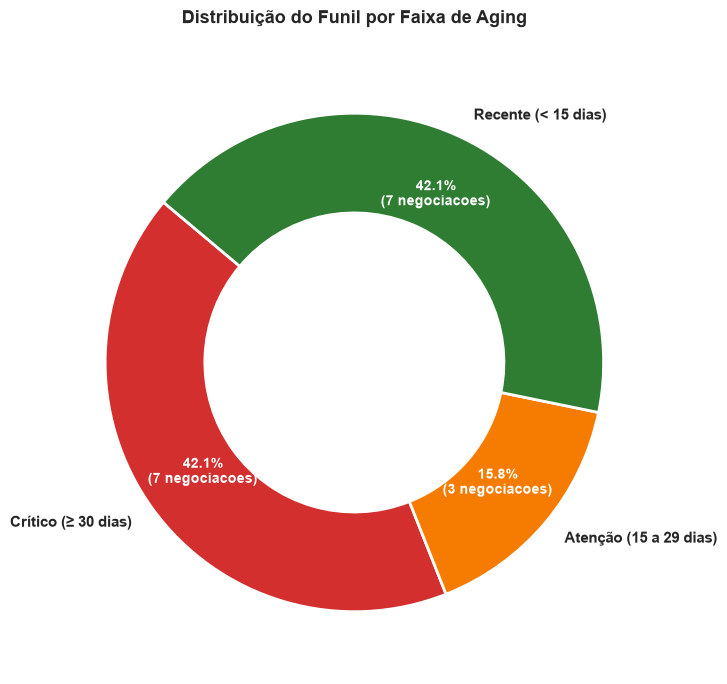

In [58]:
df_sp_neg["faixa_dias"] = pd.cut(
    df_sp_neg["dias_no_funil"],
    bins=[-1, 14, 29, 999],
    labels=[
        "Recente (< 15 dias)",
        "Atenção (15 a 29 dias)",
        "Crítico (≥ 30 dias)",
    ],
)

resumo = (
    df_sp_neg["faixa_dias"]
    .value_counts()
    .reindex(
        ["Crítico (≥ 30 dias)", "Atenção (15 a 29 dias)", "Recente (< 15 dias)"]
    )
)

fig, ax = plt.subplots(figsize=(12, 7))
colors_donut = ["#D32F2F", "#F57C00", "#2E7D32"]

wedges, texts, autotexts = ax.pie(
    resumo,
    labels=resumo.index,
    autopct=lambda p: f"{p:.1f}%\n({int(p*sum(resumo)/100)} negociacoes)",
    startangle=140,
    colors=colors_donut,
    wedgeprops=dict(width=0.4, edgecolor="w", linewidth=2),
    pctdistance=0.75,
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11, weight="bold")
ax.set_title(
    "Distribuição do Funil por Faixa de Aging",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()

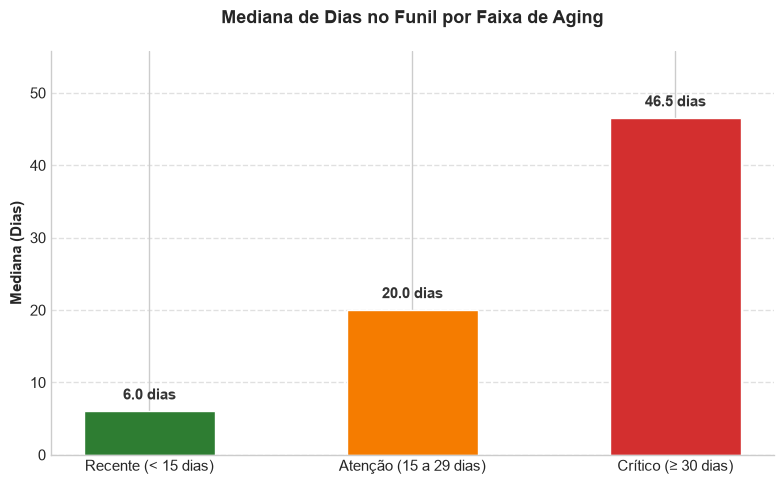

In [59]:
mediana_faixa = (
    df_sp_neg.groupby("faixa_dias", observed=False)["dias_no_funil"]
    .median()
    .reset_index()
)

ordem = ["Recente (< 15 dias)", "Atenção (15 a 29 dias)", "Crítico (≥ 30 dias)"]
mediana_faixa["faixa_dias"] = pd.Categorical(
    mediana_faixa["faixa_dias"], categories=ordem, ordered=True
)
mediana_faixa = mediana_faixa.sort_values("faixa_dias")

cores = ["#2E7D32", "#F57C00", "#D32F2F"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    mediana_faixa["faixa_dias"],
    mediana_faixa["dias_no_funil"],
    color=cores,
    width=0.5,
)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.2,
        f"{yval:.1f} dias",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#333333",
    )

ax.set_title(
    "Mediana de Dias no Funil por Faixa de Aging",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_ylabel("Mediana (Dias)", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(mediana_faixa["dias_no_funil"]) * 1.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

**Principais Achados & Próximos Passos Comerciais**

- Gargalo no topo da tabela: Quase metade das contas em aberto (42%) ultrapassou 1 mês de negociação. As 4 primeiras contas (Hering, Laguna, Grupo La Moda, Usaflex) estão empacadas há 52 dias. Vale verificar se houve objeção técnica/comercial ou falta de retorno do cliente.

- Giro recente bom: O volume de leads novos (< 7 dias) demonstra bom fluxo na entrada. O desafio central não é prospecção, mas o desfecho/ganho de tração nas contas mais maduras.

- Ponto de Estagnação: A mediana salta de 20 dias no grupo de atenção para 46,5 dias no grupo crítico. Esse salto abrupto demonstra que as negociações que passam da marca de 30 dias não estão apenas "um pouco atrasadas", mas sim completamente paradas há mais de um mês e meio.

- Uso da Mediana vs Média: A mediana é a métrica correta aqui por não sofrer distorção dos valores extremos (como o grupo do topo com 52 dias cravados). Ela mostra exatamente o "comportamento típico" de uma conta dentro de cada estágio do funil.

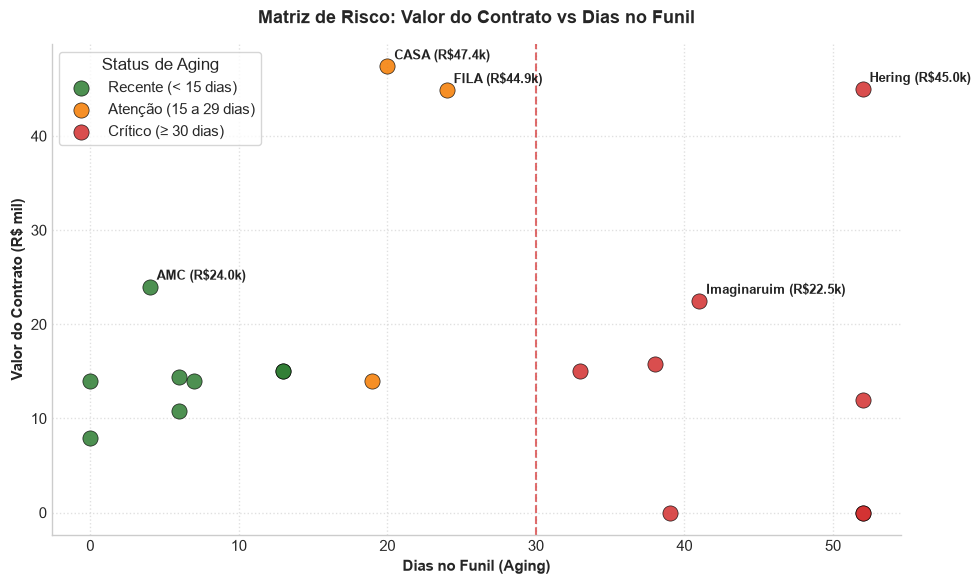

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

cores = {
    "Crítico (≥ 30 dias)": "#D32F2F",
    "Atenção (15 a 29 dias)": "#F57C00",
    "Recente (< 15 dias)": "#2E7D32",
}

for faixa, group in df_sp_neg.groupby("faixa_dias", observed=False):
    ax.scatter(
        group["dias_no_funil"],
        group["valor_contrato"] / 1000,
        s=120,
        color=cores[faixa],
        label=faixa,
        alpha=0.85,
        edgecolors="black",
        linewidth=0.5,
    )

destaques = df_sp_neg[df_sp_neg["valor_contrato"] >= 20000]
for _, row in destaques.iterrows():
    ax.annotate(
        f"{row['titular_nome'].split(' ')[0]} (R${row['valor_contrato']/1000:.1f}k)",
        (row["dias_no_funil"], row["valor_contrato"] / 1000),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="#222222",
    )

ax.axvline(x=30, color="#D32F2F", linestyle="--", alpha=0.7)
ax.set_title(
    "Matriz de Risco: Valor do Contrato vs Dias no Funil",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Dias no Funil (Aging)", fontsize=11, fontweight="bold")
ax.set_ylabel("Valor do Contrato (R$ mil)", fontsize=11, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Status de Aging", frameon=True)

plt.tight_layout()

**Matriz de Risco (Scatter Plot: Valor x Aging)**

Este é o gráfico definitivo para o time de vendas. Ele cruza o tempo de travamento com o tamanho do ticket, dividindo as contas em 4 quadrantes implícitos:

- Topo Direito (Crítico + Alto Valor): Hering (R$ 45k) e Imaginarium (R$ 22.5k) estão velhas e valem muito. São o risco primário do funil.

- Topo Centro (Atenção + Alto Valor): CASA MODA (R$ 47.4k) e FILA BRASIL (R$ 44.9k) estão prestes a virar o mês, mas valem juntas quase R$ 92k. É o sweet spot de atuação imediata antes de azedar.

- Base Direita (Crítico + R$ 0 / Baixo Valor): Marcas sem valor definido ou abaixo de R$ 20k com 52 dias (Grupo La Moda, Usaflex, Melissa, Laguna Shop, Piet Org, Kayland Comercio). Precisam ser qualificadas/precificadas urgente ou descartadas para não poluir o CRM.

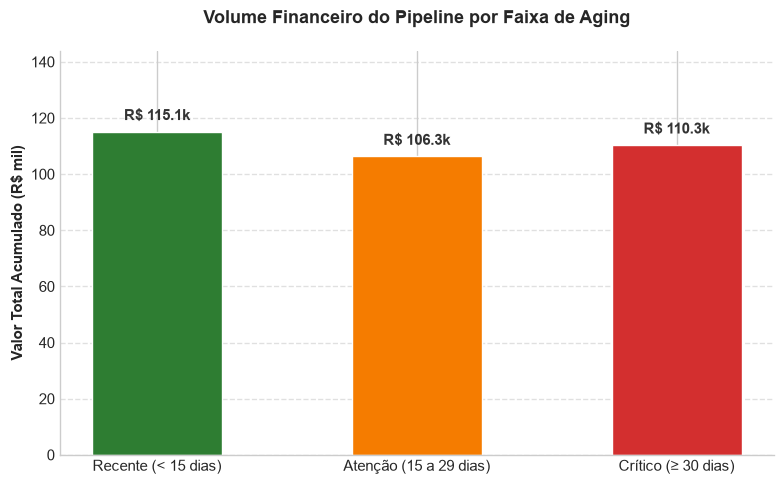

In [62]:
receita_faixa = (
    df_sp_neg.groupby("faixa_dias", observed=False)["valor_contrato"]
    .sum()
    .reindex(
        [
            "Recente (< 15 dias)",
            "Atenção (15 a 29 dias)",
            "Crítico (≥ 30 dias)",
        ]
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
cores_bars = ["#2E7D32", "#F57C00", "#D32F2F"]

bars = ax.bar(
    receita_faixa.index, receita_faixa.values / 1000, color=cores_bars, width=0.5
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 3,
        f"R$ {height:.1f}k",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#333333",
    )

ax.set_title(
    "Volume Financeiro do Pipeline por Faixa de Aging",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_ylabel("Valor Total Acumulado (R$ mil)", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(receita_faixa.values / 1000) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

**Volume Financeiro Acumulado por Faixa de Aging**

Total do pipeline ativo em SP: R$ 331.680,00. O achado interessante aqui é que o dinheiro está distribuído quase que igualmente em terços entre as três faixas:

- Recente (< 15 dias): R$ 115.1k (34.7%)

- Atenção (15 a 29 dias): R$ 106.3k (32.0%)

- Crítico (≥ 30 dias): R$ 110.3k (33.3%)

**Insight Comercial de Impacto**

Existem R$ 110.300,00 parados na zona crítica (≥ 30 dias). No entanto, o maior ganho de curto prazo está na faixa de Atenção (R$ 106.3k com apenas 3 negociações), puxada quase que inteiramente por CASA MODA e FILA BRASIL. Salvar essas duas negociações garante 32% de conversão de todo o financeiro do funil.

# Conclusão e Plano de Ação Comercial

A análise integrada do aging e do volume financeiro do pipeline de São Paulo indica que o gargalo do funil não está na atração de novos leads, mas na estagnação das contas em fase avançada de negociação.

Com um valor total acumulado de R$ 331.680,00 distribuído em 19 oportunidades, os dados apontam para três frentes estratégicas de atuação:

- **Prioridade Zero (Receita de Curto Prazo):** A faixa de Atenção (15 a 29 dias) concentra R$ 106.280,00 em apenas 3 contas, com destaque absoluto para CASA MODA (R$ 47,4k) e FILA BRASIL (R$ 44,9k). O esforço de follow-up da equipe deve ser direcionado imediatamente a esses dois alvos para fechar a conversão antes que cruzem a barreira dos 30 dias.

- **Resgate do Bloco Crítico:** A zona Crítica (≥ 30 dias) acumula R$ 110.300,00 (42,1% das negociações), com mediana de travamento em 46,5 dias. Contas de alto valor como Hering (R$ 45k) e Imaginarium (R$ 22,5k) exigem intervenção executiva ou renegociação de escopo para destravar a decisão.

- **Higienização do CRM (Limpeza de Funil):** Negociações com 52 dias de aging e valor zerado (Grupo La Moda, Usaflex e Melissa) estão poluindo a métrica do funil e distorcendo a produtividade do time. É necessário estabelecer um critério rígido de qualificação: ou precifica-se a proposta em até 48 horas ou o card deve ser movido para Perdido/Inativo.

- **Nova Cadência e SLA de Negociação (Máx. 5 Dias):** Dado o tempo restante até o evento e para nivelar (ou superar) a velocidade do ciclo de vida observado em outros mercados como o Rio, implementar uma cadência agressiva de acompanhamento com teto de 5 dias na etapa de negociação. prevendo pontos de contato diários e alternados (ligação, WhatsApp e e-mail), reduzindo drasticamente o tempo de resposta e evitando que novas oportunidades esfriem.